# Heart Health Classification with Decision Trees

## Two academic classification case studies

This self-contained project investigates two supervised classification problems using Decision Trees:

1. **Case A - Chest Pain Type Classification:** a four-class problem that predicts `ChestPainType`.
2. **Case B - Heart Disease Classification:** a binary problem that predicts `HeartDisease`.

The analysis combines data-quality assessment, interpretable preprocessing, stratified validation, class-level performance evaluation and visual interpretation of the fitted trees.

> **Educational disclaimer:** This analysis explores statistical patterns in a public dataset. It is not a medical diagnostic system.

## 1. Importing Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42
DATA_PATH = Path(r"E:\data\heart.csv")

print(f"Dataset path: {DATA_PATH}")

Dataset path: E:\data\heart.csv


## 2. Data Loading and Quality Assessment

The public Heart Failure Prediction dataset contains 12 attributes and 918 observations.

Before modelling, the analysis checks the dataset dimensions, data types, duplicate rows, missing values and target distributions. These checks ensure that both classification cases use a consistent and valid analytical sample.

In [2]:
heart = pd.read_csv(DATA_PATH)

print(f"Rows: {heart.shape[0]:,}")
print(f"Columns: {heart.shape[1]}")
print(f"Exact duplicate rows: {heart.duplicated().sum()}")
print(f"Missing values: {heart.isna().sum().sum()}")

display(heart.head())
display(heart.describe(include="all").T)

Rows: 918
Columns: 12
Exact duplicate rows: 0
Missing values: 0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


### Clinical Variable Interpretation

The exploratory analysis uses the following interpretations:

- `RestingBP` represents resting blood pressure.
- Most cholesterol measurements lie roughly between 120 and 350, with some extreme values.
- A value of zero for `Cholesterol` is treated as an unavailable measurement, not genuine zero cholesterol.
- The four chest-pain classes are `TA`, `ATA`, `NAP` and `ASY`.

The same zero-as-unavailable treatment is applied to `RestingBP`. Imputation is performed inside each modelling pipeline so that the validation data do not influence the learned replacement values.

Zero placeholders before correction:


,Count
Cholesterol,172
RestingBP,1


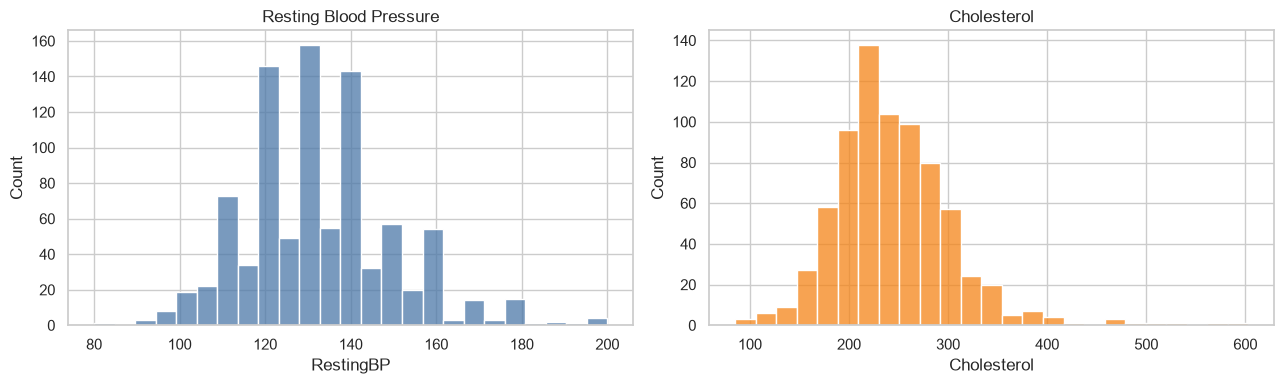

In [3]:
zero_placeholders = {
    column: int((heart[column] == 0).sum())
    for column in ["Cholesterol", "RestingBP"]
}

print("Zero placeholders before correction:")
display(pd.Series(zero_placeholders, name="Count").to_frame())

heart_clean = heart.copy()
heart_clean[["Cholesterol", "RestingBP"]] = heart_clean[
    ["Cholesterol", "RestingBP"]
].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(heart_clean["RestingBP"], bins=25, ax=axes[0], color="#4C78A8")
axes[0].set_title("Resting Blood Pressure")

sns.histplot(heart_clean["Cholesterol"], bins=25, ax=axes[1], color="#F58518")
axes[1].set_title("Cholesterol")

plt.tight_layout()
plt.show()

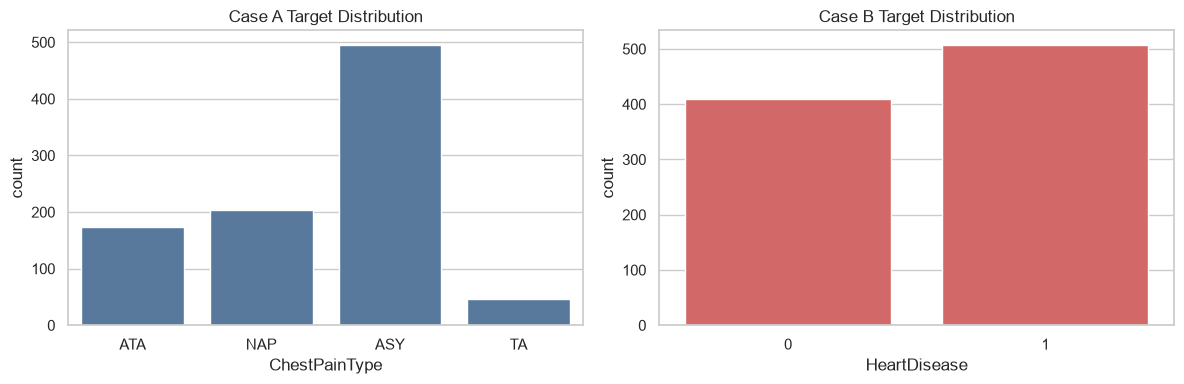

,Customers
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


,Patients
HeartDisease,
0,410
1,508


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=heart_clean, x="ChestPainType", ax=axes[0], color="#4C78A8")
axes[0].set_title("Case A Target Distribution")

sns.countplot(data=heart_clean, x="HeartDisease", ax=axes[1], color="#E45756")
axes[1].set_title("Case B Target Distribution")

plt.tight_layout()
plt.show()

display(heart_clean["ChestPainType"].value_counts().to_frame("Customers"))
display(heart_clean["HeartDisease"].value_counts().sort_index().to_frame("Patients"))

## 3. Case A - Four-Class Chest Pain Type Classification

The first case examines whether a patient's chest-pain category can be predicted from:

- Age
- Cholesterol
- Fasting blood sugar
- Maximum heart rate
- Resting blood pressure
- Sex

The analysis focuses on patients aged 35 or older. Age and Cholesterol are divided into three quantile-based groups, with the bin boundaries learned inside the model pipeline to avoid information leakage.

Because `ChestPainType` is an imbalanced four-class target, accuracy is evaluated together with balanced accuracy, macro F1 and the class-level confusion matrix.

In [5]:
case_a = heart_clean.loc[heart_clean["Age"] >= 35].copy()

case_a_features = [
    "Age",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "RestingBP",
    "Sex",
]

X_a = case_a[case_a_features]
y_a = case_a["ChestPainType"]

X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a,
    y_a,
    test_size=0.20,
    stratify=y_a,
    random_state=RANDOM_STATE,
)

print(f"Rows after Age >= 35 filter: {len(case_a):,}")
print(f"Training rows: {len(X_a_train):,}")
print(f"Holdout rows: {len(X_a_test):,}")

Rows after Age >= 35 filter: 897
Training rows: 717
Holdout rows: 180


In [6]:
case_a_preprocess = ColumnTransformer(
    transformers=[
        (
            "binned",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "quantile_bins",
                        KBinsDiscretizer(
                            n_bins=3,
                            encode="ordinal",
                            strategy="quantile",
                        ),
                    ),
                ]
            ),
            ["Age", "Cholesterol"],
        ),
        (
            "numeric",
            SimpleImputer(strategy="median"),
            ["FastingBS", "MaxHR", "RestingBP"],
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ["Sex"],
        ),
    ],
    verbose_feature_names_out=False,
)

case_a_model = Pipeline(
    steps=[
        ("preprocess", case_a_preprocess),
        (
            "decision_tree",
            DecisionTreeClassifier(
                criterion="entropy",
                max_depth=11,
                min_samples_leaf=3,
                min_samples_split=3,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [7]:
cv_a = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE,
)

case_a_cv = cross_validate(
    case_a_model,
    X_a_train,
    y_a_train,
    cv=cv_a,
    scoring={
        "Accuracy": "accuracy",
        "Balanced Accuracy": "balanced_accuracy",
        "Macro F1": "f1_macro",
    },
)

case_a_cv_summary = pd.DataFrame(
    {
        metric: [case_a_cv[f"test_{metric}"].mean(), case_a_cv[f"test_{metric}"].std()]
        for metric in ["Accuracy", "Balanced Accuracy", "Macro F1"]
    },
    index=["Mean", "Standard Deviation"],
).T

display(case_a_cv_summary.round(3))

,Mean,Standard Deviation
Accuracy,0.484,0.052
Balanced Accuracy,0.317,0.067
Macro F1,0.320,0.079


,Case A Holdout
Accuracy,0.494
Balanced Accuracy,0.314
Macro F1,0.320
Kappa,0.115


,precision,recall,f1-score,support
ASY,0.630,0.758,0.688,99.000
ATA,0.222,0.250,0.235,32.000
NAP,0.217,0.122,0.156,41.000
TA,0.500,0.125,0.200,8.000
accuracy,0.494,0.494,0.494,0.494
macro avg,0.392,0.314,0.320,180.000
weighted avg,0.458,0.494,0.465,180.000


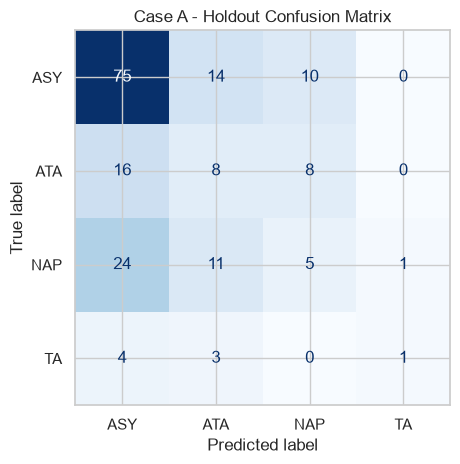

In [8]:
case_a_model.fit(X_a_train, y_a_train)
case_a_predictions = case_a_model.predict(X_a_test)

case_a_holdout = {
    "Accuracy": accuracy_score(y_a_test, case_a_predictions),
    "Balanced Accuracy": balanced_accuracy_score(y_a_test, case_a_predictions),
    "Macro F1": f1_score(y_a_test, case_a_predictions, average="macro"),
    "Kappa": cohen_kappa_score(y_a_test, case_a_predictions),
}

display(pd.Series(case_a_holdout, name="Case A Holdout").to_frame().round(3))
display(pd.DataFrame(classification_report(y_a_test, case_a_predictions, output_dict=True)).T.round(3))

ConfusionMatrixDisplay.from_predictions(
    y_a_test,
    case_a_predictions,
    cmap="Blues",
    colorbar=False,
)
plt.title("Case A - Holdout Confusion Matrix")
plt.tight_layout()
plt.show()

### Case A Interpretation

The Decision Tree creates combinations of age, maximum heart rate, fasting blood sugar, cholesterol, resting blood pressure and sex to separate the four chest-pain categories.

The confusion matrix is particularly important here: the majority `ASY` class is easier to identify, while the smaller `ATA`, `NAP` and especially `TA` groups are more difficult. Consequently, balanced accuracy and macro F1 provide a more realistic assessment than overall accuracy alone.

The visualised branches describe associations within this dataset. Their thresholds should not be interpreted as medical rules or causal relationships.

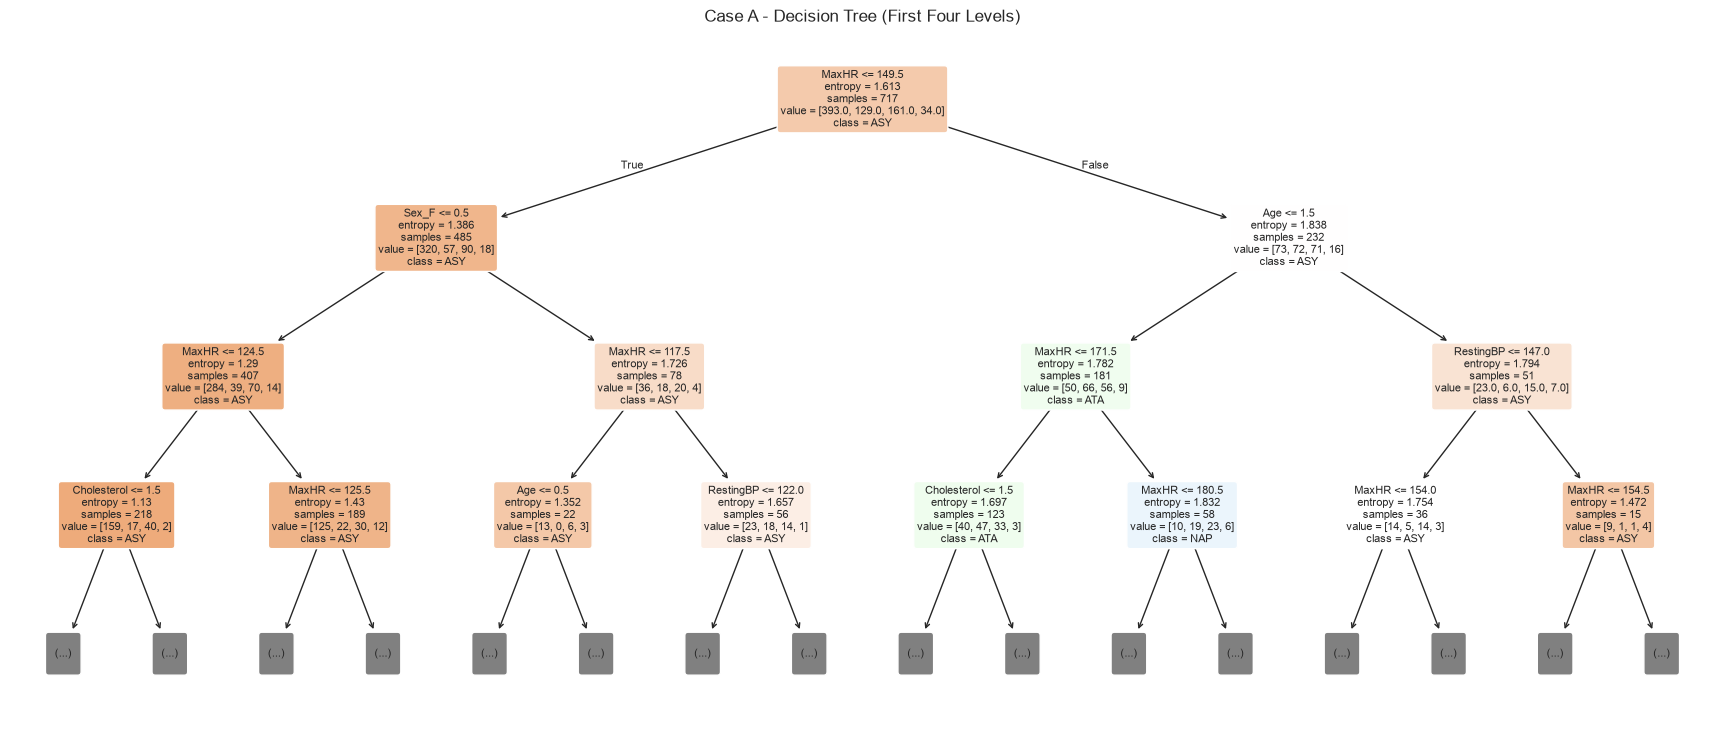

In [9]:
case_a_feature_names = case_a_model.named_steps["preprocess"].get_feature_names_out()
case_a_tree = case_a_model.named_steps["decision_tree"]

plt.figure(figsize=(22, 9))
plot_tree(
    case_a_tree,
    feature_names=case_a_feature_names,
    class_names=[str(label) for label in case_a_tree.classes_],
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Case A - Decision Tree (First Four Levels)")
plt.show()

## 4. Case B - Binary Heart Disease Classification

The second case predicts whether heart disease is present using:

- Age
- Chest pain type
- Cholesterol
- Exercise-induced angina
- Fasting blood sugar
- Resting blood pressure
- Resting ECG
- Sex

`Cholesterol` and `RestingBP` are divided into three quantile-based groups. Missing-value treatment, categorical encoding and binning are performed inside the pipeline.

The model is evaluated using accuracy, balanced accuracy, F1, ROC AUC, kappa, a class-level report and a confusion matrix.

In [10]:
case_b_features = [
    "Age",
    "ChestPainType",
    "Cholesterol",
    "ExerciseAngina",
    "FastingBS",
    "RestingBP",
    "RestingECG",
    "Sex",
]

X_b = heart_clean[case_b_features]
y_b = heart_clean["HeartDisease"]

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b,
    y_b,
    test_size=0.20,
    stratify=y_b,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_b_train):,}")
print(f"Holdout rows: {len(X_b_test):,}")

Training rows: 734
Holdout rows: 184


In [11]:
case_b_preprocess = ColumnTransformer(
    transformers=[
        (
            "binned",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "quantile_bins",
                        KBinsDiscretizer(
                            n_bins=3,
                            encode="ordinal",
                            strategy="quantile",
                        ),
                    ),
                ]
            ),
            ["Cholesterol", "RestingBP"],
        ),
        (
            "numeric",
            SimpleImputer(strategy="median"),
            ["Age", "FastingBS"],
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ["ChestPainType", "ExerciseAngina", "RestingECG", "Sex"],
        ),
    ],
    verbose_feature_names_out=False,
)

case_b_model = Pipeline(
    steps=[
        ("preprocess", case_b_preprocess),
        (
            "decision_tree",
            DecisionTreeClassifier(
                criterion="entropy",
                max_depth=12,
                min_samples_leaf=2,
                min_samples_split=4,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [12]:
cv_b = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE,
)

case_b_cv = cross_validate(
    case_b_model,
    X_b_train,
    y_b_train,
    cv=cv_b,
    scoring={
        "Accuracy": "accuracy",
        "Balanced Accuracy": "balanced_accuracy",
        "F1": "f1",
        "ROC AUC": "roc_auc",
    },
)

case_b_cv_summary = pd.DataFrame(
    {
        metric: [case_b_cv[f"test_{metric}"].mean(), case_b_cv[f"test_{metric}"].std()]
        for metric in ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC"]
    },
    index=["Mean", "Standard Deviation"],
).T

display(case_b_cv_summary.round(3))

,Mean,Standard Deviation
Accuracy,0.734,0.045
Balanced Accuracy,0.732,0.049
F1,0.759,0.037
ROC AUC,0.759,0.057


,Case B Holdout
Accuracy,0.772
Balanced Accuracy,0.774
F1,0.786
ROC AUC,0.818
Kappa,0.542


,precision,recall,f1-score,support
0,0.722,0.793,0.756,82.000
1,0.819,0.755,0.786,102.000
accuracy,0.772,0.772,0.772,0.772
macro avg,0.771,0.774,0.771,184.000
weighted avg,0.776,0.772,0.772,184.000


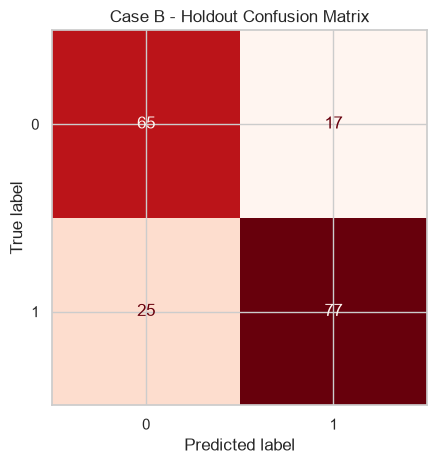

In [13]:
case_b_model.fit(X_b_train, y_b_train)
case_b_predictions = case_b_model.predict(X_b_test)
case_b_probabilities = case_b_model.predict_proba(X_b_test)[:, 1]

case_b_holdout = {
    "Accuracy": accuracy_score(y_b_test, case_b_predictions),
    "Balanced Accuracy": balanced_accuracy_score(y_b_test, case_b_predictions),
    "F1": f1_score(y_b_test, case_b_predictions),
    "ROC AUC": roc_auc_score(y_b_test, case_b_probabilities),
    "Kappa": cohen_kappa_score(y_b_test, case_b_predictions),
}

display(pd.Series(case_b_holdout, name="Case B Holdout").to_frame().round(3))
display(pd.DataFrame(classification_report(y_b_test, case_b_predictions, output_dict=True)).T.round(3))

ConfusionMatrixDisplay.from_predictions(
    y_b_test,
    case_b_predictions,
    cmap="Reds",
    colorbar=False,
)
plt.title("Case B - Holdout Confusion Matrix")
plt.tight_layout()
plt.show()

### Case B Interpretation

The fitted model gives the greatest importance to Age and the `ASY` chest-pain category. Exercise-induced angina and fasting blood sugar also contribute meaningfully, followed by resting blood pressure, cholesterol, ECG patterns and sex.

This supports a multivariable interpretation: the prediction is based on combinations of demographic, symptomatic and clinical attributes rather than a single measurement. The feature-importance chart and truncated tree make these relationships visible without presenting the complete tree as a set of medical rules.

Feature importance describes how this specific model uses the available variables; it does not establish medical causality.

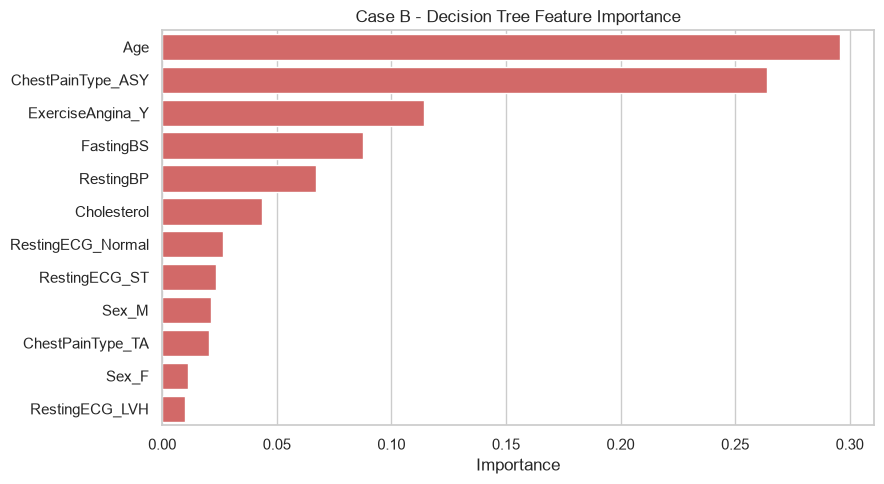

,Importance
Age,0.296
ChestPainType_ASY,0.264
ExerciseAngina_Y,0.114
FastingBS,0.088
RestingBP,0.067
Cholesterol,0.044
RestingECG_Normal,0.027
RestingECG_ST,0.024
Sex_M,0.021
ChestPainType_TA,0.021


In [14]:
case_b_feature_names = case_b_model.named_steps["preprocess"].get_feature_names_out()
case_b_tree = case_b_model.named_steps["decision_tree"]

case_b_importance = (
    pd.Series(case_b_tree.feature_importances_, index=case_b_feature_names)
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=case_b_importance.values, y=case_b_importance.index, color="#E45756")
plt.title("Case B - Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(case_b_importance.to_frame("Importance").round(3))

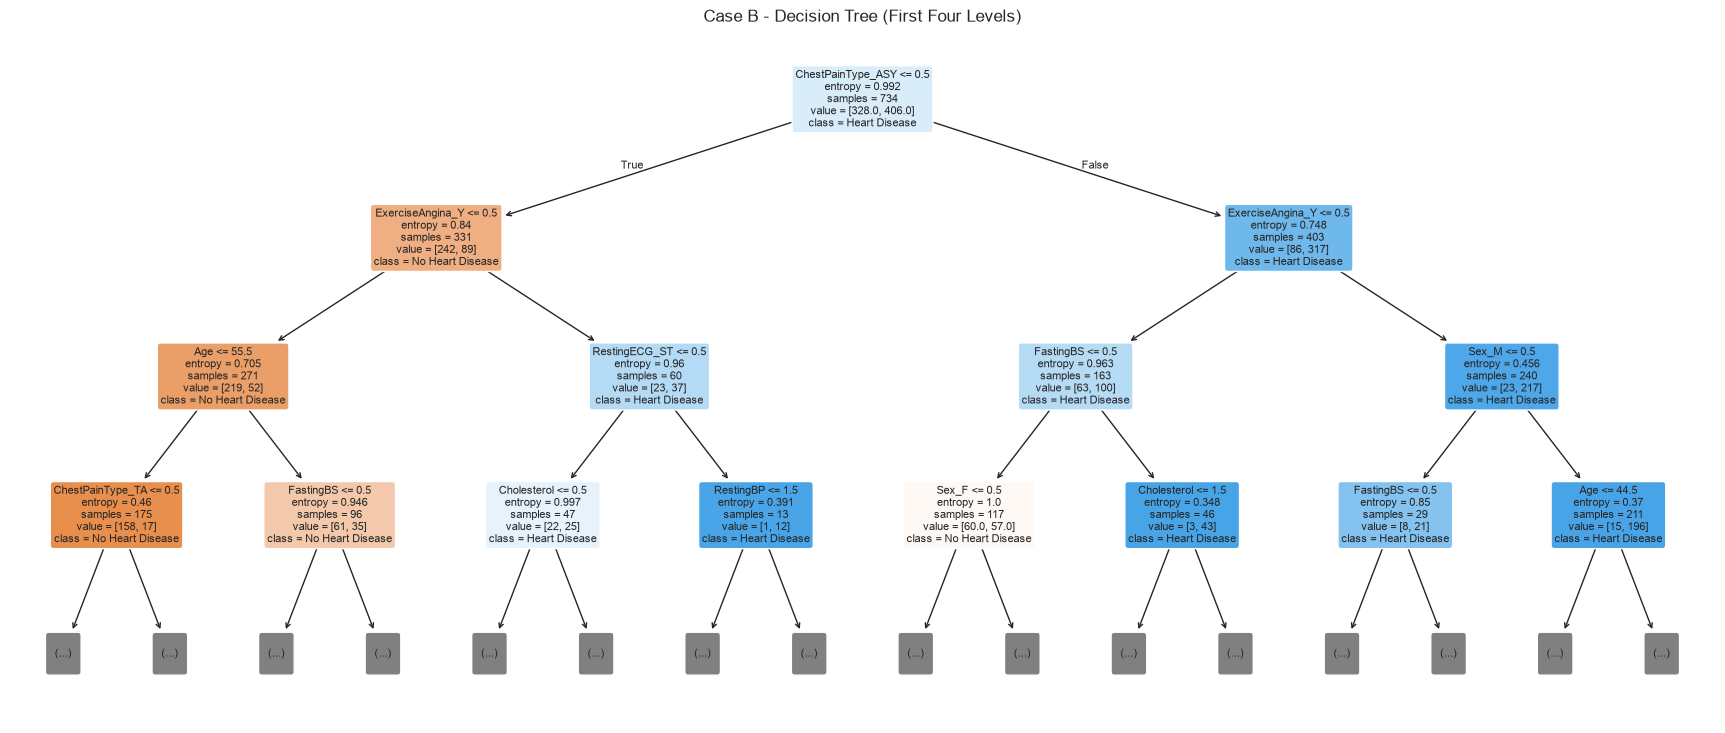

In [15]:
plt.figure(figsize=(22, 9))
plot_tree(
    case_b_tree,
    feature_names=case_b_feature_names,
    class_names=["No Heart Disease", "Heart Disease"],
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Case B - Decision Tree (First Four Levels)")
plt.show()

## 5. Final Comparison and Conclusions

The two cases answer different questions, so their accuracy values should not be compared as if they predict the same target.

- **Case A** is harder because it separates four imbalanced chest-pain categories. Balanced accuracy and macro F1 reveal the difficulty of identifying the smaller classes.
- **Case B** provides the stronger predictive result. Its binary target is more balanced, and the model achieves useful discrimination on both cross-validation and holdout evaluation.
- The shared validation design makes the methodology reproducible: stratified holdout testing, stratified 10-fold cross-validation and preprocessing contained inside each pipeline.
- Decision-tree visualisations provide transparency, but the observed splits remain dataset-specific associations.

### Overall Assessment

The project demonstrates how one cardiovascular dataset can support two related but distinct classification questions:

> Which chest-pain category best describes an observation, and how accurately can the available attributes identify the presence of heart disease?